# Anime Face GAN — DCGAN Architecture and Training

A Generative Adversarial Network is a system of two neural networks in competition. The **generator** learns to produce images from random noise. The **discriminator** learns to distinguish real images from generated ones. Neither network can win permanently — the generator improves to fool the discriminator, the discriminator improves to catch the generator, and both get better together. The result is a generator that has learned to produce images indistinguishable from the training data.

This project trains a DCGAN on 63,000 anime face images. The training runs on **Azure ML Compute Instance** — demonstrating cloud-based model training separate from the deployment infrastructure.

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
from pathlib import Path

from config import (
    DATA_DIR,
    IMG_SIZE, IMG_SHAPE, LATENT_DIM,
    EPOCHS, BATCH_SIZE, LEARNING_RATE_G, LEARNING_RATE_D, BETA_1,
    SAVE_INTERVAL, N_SAMPLES,
)

print(f'TensorFlow {tf.__version__}')
print(f'GPUs: {tf.config.list_physical_devices("GPU")}')

In [ ]:
import os, sys
from pathlib import Path

IN_COLAB  = 'google.colab' in sys.modules
IN_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ

# ── Where are the trained model files? ──────────────────────────────────────
# Auto-detected, but override manually if needed:
#   MODEL_DIR   = Path('models')                          # local
#   MODEL_DIR   = Path('/content/drive/MyDrive/anime-face-gan/models')  # Colab

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    MODEL_DIR   = Path('/content/drive/MyDrive/anime-face-gan/models')
    SAMPLES_DIR = Path('/content/drive/MyDrive/anime-face-gan/samples')
    print(f'Colab — reading models from Google Drive: {MODEL_DIR}')
else:
    from config import MODEL_DIR, SAMPLES_DIR
    print(f'Local — reading models from: {MODEL_DIR}')

## The GAN Training Dynamic

The generator and discriminator have opposing objectives expressed as a minimax game. The discriminator tries to maximise its ability to classify real vs fake. The generator tries to minimise the discriminator's ability to do so.

Formally:
$$\min_G \max_D \left[ \mathbb{E}[\log D(x)] + \mathbb{E}[\log(1 - D(G(z)))] \right]$$

where $x$ is a real image, $z$ is random noise, $G(z)$ is a generated image, and $D(x)$ is the discriminator's probability that $x$ is real.

In practice this means: if the discriminator is too strong, the generator gets no useful gradient signal. If the generator is too strong, the discriminator collapses. The training is inherently unstable — the architectural choices (BatchNorm, Dropout, LeakyReLU, BETA_1=0.5) are specifically designed to stabilise this dynamic.

In [3]:
import shutil
import kagglehub

existing = list(DATA_DIR.glob('*.jpg')) + list(DATA_DIR.glob('*.png'))

if existing:
    print(f'Dataset already present — {len(existing):,} images in {DATA_DIR}')
else:
    print('Downloading Anime Face Dataset (~330MB)...\n')

    # kagglehub accepts credentials in two ways (both work, pick one):
    #
    # Option A — file (local machines):
    #   mkdir -p ~/.kaggle && mv ~/Downloads/kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
    #
    # Option B — environment variables (Colab, CI, other machines):
    #   export KAGGLE_USERNAME=your_username
    #   export KAGGLE_KEY=your_api_key
    #   (get both from kaggle.com → Settings → API → Create New Token)

    try:
        src = Path(kagglehub.dataset_download('splcher/animefacedataset'))
    except Exception as e:
        print('Authentication failed. Set up Kaggle credentials with one of:\n')
        print('  Option A — file:')
        print('    mkdir -p ~/.kaggle')
        print('    mv ~/Downloads/kaggle.json ~/.kaggle/')
        print('    chmod 600 ~/.kaggle/kaggle.json\n')
        print('  Option B — environment variables:')
        print('    export KAGGLE_USERNAME=your_username')
        print('    export KAGGLE_KEY=your_api_key')
        print('  (get both from kaggle.com → Settings → API → Create New Token)')
        raise

    print(f'Downloaded to cache: {src}')
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    images = list(src.rglob('*.jpg')) + list(src.rglob('*.png'))
    for p in images:
        shutil.copy(p, DATA_DIR / p.name)
    print(f'Copied {len(images):,} images → {DATA_DIR}')

Dataset already present — 63,565 images in data/anime_faces


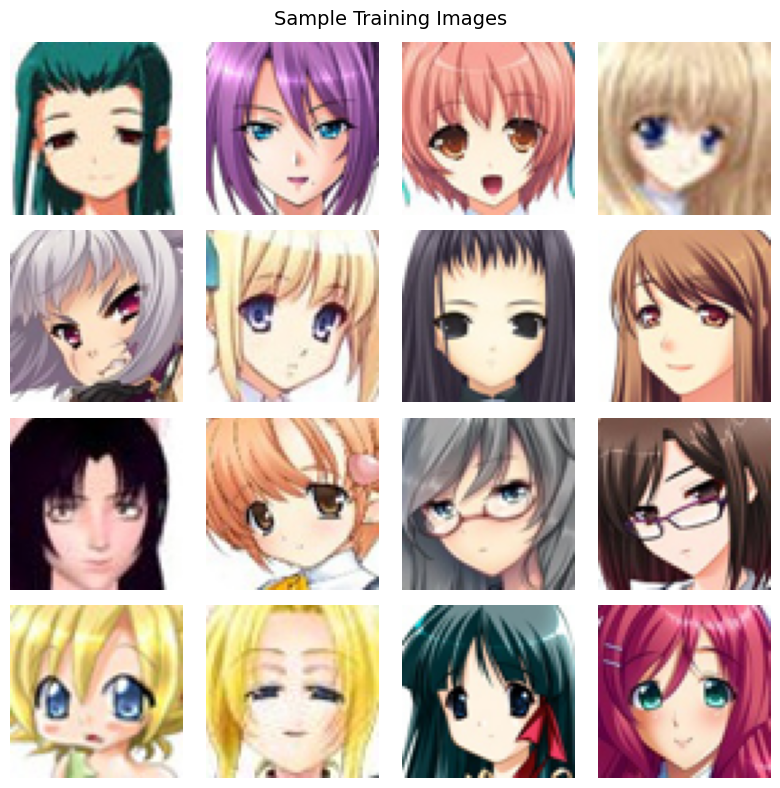

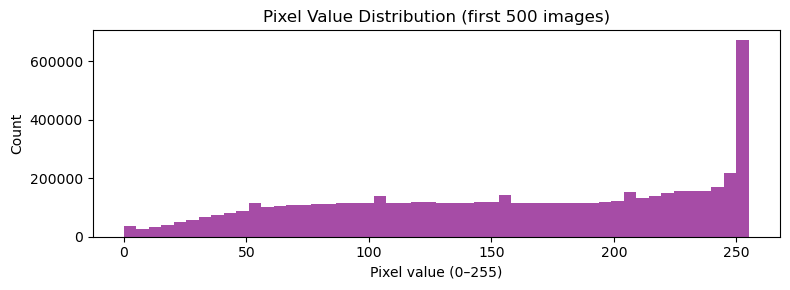

Total images: 63565
Image shape after resize: (64, 64, 3)
Normalised range: [-1, 1]


In [4]:
# Load and display sample training images
image_paths = list(DATA_DIR.glob('*.jpg'))[:16] + list(DATA_DIR.glob('*.png'))[:16]
image_paths = image_paths[:16]

if image_paths:
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    fig.suptitle('Sample Training Images', fontsize=14)
    for ax, p in zip(axes.flat, image_paths):
        img = Image.open(p).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    # Pixel distribution
    all_pixels = []
    for p in list(DATA_DIR.glob('*.jpg'))[:500]:
        arr = np.array(Image.open(p).convert('RGB').resize((IMG_SIZE, IMG_SIZE)))
        all_pixels.append(arr.flatten())
    all_pixels = np.concatenate(all_pixels)
    plt.figure(figsize=(8, 3))
    plt.hist(all_pixels, bins=50, color='purple', alpha=0.7)
    plt.title('Pixel Value Distribution (first 500 images)')
    plt.xlabel('Pixel value (0–255)')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    total = len(list(DATA_DIR.glob('*.jpg'))) + len(list(DATA_DIR.glob('*.png')))
    print(f'Total images: {total}')
    print(f'Image shape after resize: ({IMG_SIZE}, {IMG_SIZE}, 3)')
    print(f'Normalised range: [-1, 1]')
else:
    print('Dataset not found. Download with one of:\n')
    print('  Option A — kagglehub (recommended):')
    print('    pip install kagglehub')
    print('    python -c "import kagglehub; kagglehub.dataset_download(\'splcher/animefacedataset\')"')
    print('    # then copy images into data/anime_faces/')
    print()
    print('  Option B — Kaggle CLI:')
    print('    kaggle datasets download -d splcher/animefacedataset')
    print('    unzip animefacedataset.zip -d data/anime_faces/')
    print()
    print('  Option C — manual download:')
    print('    https://www.kaggle.com/datasets/splcher/animefacedataset')
    print()
    print('Showing placeholder grid (random colours) to demonstrate layout:')
    rng = np.random.default_rng(0)
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    fig.suptitle('Sample Training Images  [placeholder — dataset not downloaded]',
                 fontsize=12, color='gray')
    for ax in axes.flat:
        placeholder = rng.integers(80, 220, (IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        ax.imshow(placeholder)
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    print(f'Expected: 63,000 images at ({IMG_SIZE}, {IMG_SIZE}, 3), normalised to [-1, 1]')

## Generator Architecture — Building Images from Noise

The generator maps a 128-dimensional noise vector to a 64×64 RGB image through a series of transposed convolutions.

**Input:** random noise vector `z` of shape `(128,)` — sampled from a standard normal distribution  
**Output:** image of shape `(64, 64, 3)` with values in `[−1, 1]`

**Upsampling path:** 4×4 → 8×8 → 16×16 → 32×32 → 64×64

Each `Conv2DTranspose` with `strides=(2,2)` doubles the spatial dimensions — the inverse of a strided `Conv2D`. The generator starts with a small but deep feature map (4×4×512) and gradually reduces channels while increasing spatial resolution.

**Why tanh output?** The training images are normalised to `[−1, 1]`. Using `tanh` ensures the generator output is in the same range — if the generator used `sigmoid` and the real images were in `[−1, 1]`, the discriminator would trivially distinguish real from fake by value range alone.

**BatchNormalization** after every layer except the output stabilises training by keeping activations in a consistent range across the batch.

## Discriminator Architecture — Learning to Spot Fakes

The discriminator maps a 64×64 RGB image to a single probability: how likely is this image to be real?

**Input:** image of shape `(64, 64, 3)`  
**Output:** scalar in `[0, 1]` — probability the input is a real training image

**Downsampling path:** 64×64 → 32×32 → 16×16 → 8×8 → 4×4 → probability

**No BatchNorm on the first layer.** This is standard DCGAN practice. The first layer operates directly on raw pixel values; BatchNorm here can suppress the discriminator's ability to learn basic intensity statistics.

**Dropout(0.3)** appears after every conv block. The discriminator can easily overfit — it sees the same real images many times and could memorise them rather than learning general features. More importantly, if the discriminator becomes too accurate too quickly, the generator's loss gradient approaches zero: it gets no signal about how to improve. Dropout keeps the discriminator imperfect enough to provide useful gradients throughout training.

**sigmoid output** maps the final Dense unit to `[0, 1]`, interpretable as a probability.

In [5]:
from train import build_generator, build_discriminator

generator = build_generator()
discriminator = build_discriminator()

print('=== Generator ===')
generator.summary()
print(f'\nGenerator parameters: {generator.count_params():,}')

print('\n=== Discriminator ===')
discriminator.summary()
print(f'\nDiscriminator parameters: {discriminator.count_params():,}')

# Verify shapes
noise = tf.random.normal([1, LATENT_DIM])
fake_img = generator(noise, training=False)
disc_out = discriminator(fake_img, training=False)
print(f'\nNoise shape: {noise.shape}')
print(f'Generated image shape: {fake_img.shape}')
print(f'Discriminator output: {disc_out.numpy()[0][0]:.4f} (untrained, random)')

=== Generator ===


/opt/anaconda3/envs/safety_mark1/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/envs/safety_mark1/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8192)           │     1,048,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 8192)           │        32,768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 256)      │     2,097,152 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 128)    │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 64, 64, 3)      │         3,072 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,838,720 (14.64 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 512)      │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,768,321 (10.56 MB)

 Trainable params: 2,766,529 (10.55 MB)

 Non-trainable params: 1,792 (7.00 KB)


Discriminator parameters: 2,768,321

Noise shape: (1, 128)
Generated image shape: (1, 64, 64, 3)
Discriminator output: 0.5000 (untrained, random)


## Training on Azure ML

Training GANs locally is slow — 100 epochs on 63,000 64×64 colour images takes 8–12 hours on CPU. Azure ML Compute Instance provides managed cloud compute: spin up a machine, run the training script, shut it down.

The key cost control is the last line of `train.py`:

```python
import subprocess
subprocess.run(['sudo', 'shutdown', '-h', 'now'])
```

This line shuts down the compute instance the instant training finishes. Combined with a 15-minute idle shutdown setting and a \$5 budget alert, the total training cost is \$2–5.

The infrastructure story — training on cloud compute, deploying inference separately — mirrors how ML systems are built in production. The compute instance used for training is not the same machine that serves inference; Azure App Service handles all prediction requests independently.

## Training Stability — What Can Go Wrong

GAN training failure modes:

**Mode collapse:** the generator learns to produce only one or a few outputs that fool the discriminator, ignoring most of the latent space.  
Sign: all generated faces look identical.  
Fix: increase discriminator Dropout, reduce learning rate.

**Discriminator collapse:** the discriminator becomes too accurate too fast, giving the generator near-zero gradients.  
Sign: discriminator loss approaches 0, generator loss spikes.  
Fix: reduce discriminator learning rate relative to generator.

**Training oscillation:** losses oscillate wildly without converging.  
Sign: both losses fluctuate without trend.  
Fix: reduce learning rates, increase batch size.

The DCGAN architecture choices — `BETA_1=0.5`, BatchNorm, `Dropout(0.3)`, `LeakyReLU` — are specifically chosen to avoid these failures.

In [ ]:
import os, sys
from pathlib import Path

IN_COLAB  = 'google.colab' in sys.modules
IN_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ

model_dir   = MODEL_DIR
samples_dir = SAMPLES_DIR

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    model_dir   = Path('/content/drive/MyDrive/anime-face-gan/models')
    samples_dir = Path('/content/drive/MyDrive/anime-face-gan/samples')
    print(f'Colab: checkpoints → Google Drive ({model_dir})')
elif IN_KAGGLE:
    model_dir   = Path('/kaggle/working/models')
    samples_dir = Path('/kaggle/working/samples')
    import config
    config.DATA_DIR = Path('/kaggle/input/animefacedataset/images')
    print(f'Kaggle: checkpoints → {model_dir}')
else:
    print(f'Local: checkpoints → {model_dir}')

print(f'Saved every {SAVE_INTERVAL} epochs — a crash loses at most one interval.\n')

from train import train
train(model_dir=model_dir, samples_dir=samples_dir)

In [ ]:
# Load and plot training log
log_path = MODEL_DIR / 'training_log.json'

if log_path.exists():
    with open(log_path) as f:
        log = json.load(f)

    epochs = range(1, len(log['gen_loss']) + 1)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(epochs, log['gen_loss'], label='Generator loss', color='#E040FB')
    ax.plot(epochs, log['disc_loss'], label='Discriminator loss', color='#7c4dff')

    for ep in range(SAVE_INTERVAL, EPOCHS + 1, SAVE_INTERVAL):
        ax.axvline(ep, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Training Loss — Generator vs Discriminator')
    ax.legend()
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

    print(f'Final generator loss:     {log["gen_loss"][-1]:.4f}')
    print(f'Final discriminator loss: {log["disc_loss"][-1]:.4f}')

    # Show sample grids at epoch 10, 50, and final
    checkpoints = [10, 50, EPOCHS]
    fig, axes = plt.subplots(1, len(checkpoints), figsize=(15, 5))
    for ax, ep in zip(axes, checkpoints):
        p = SAMPLES_DIR / ('final_samples.png' if ep == EPOCHS else f'epoch_{ep:04d}.png')
        if p.exists():
            img = Image.open(p)
            ax.imshow(img)
            ax.set_title(f'Epoch {ep}' if ep != EPOCHS else 'Final')
        else:
            ax.set_title(f'Epoch {ep} (missing)')
        ax.axis('off')
    plt.suptitle('Generated Faces at Different Training Stages', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print(f'training_log.json not found at {log_path}. Run training first.')

## Latent Space Interpolation

If the generator has genuinely learned a structured latent space, interpolating linearly between two noise vectors should produce a smooth morphing sequence.

This is a qualitative test of generalisation: a model that has memorised training images cannot interpolate smoothly — it would jump discontinuously between images it has seen before. Smooth interpolation means the generator has learned a **continuous mapping** from noise to face space — it can produce faces it has never seen, at any point in the latent space.

The interpolation is linear in the latent space:
$$z_i = z_{\text{start}} + \alpha_i \cdot (z_{\text{end}} - z_{\text{start}}), \quad \alpha_i \in [0, 1]$$

In [ ]:
from generate import generate_interpolation

interp_path = MODEL_DIR.parent / 'samples' / 'interpolation.png'

if (MODEL_DIR / 'generator.keras').exists():
    out = generate_interpolation(steps=10, output_path=str(interp_path))
    img = Image.open(out)
    plt.figure(figsize=(14, 2))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Latent Space Interpolation — 10 Steps Between Two Random Faces')
    plt.tight_layout()
    plt.show()
    print('Smooth transitions indicate a learned continuous latent space.')
else:
    print('generator.keras not found — run training first (see azure_ml_setup.md).')
    print()
    print('Showing placeholder strip to demonstrate the interpolation layout:')
    rng = np.random.default_rng(1)
    # Simulate a smooth colour gradient across 10 steps as a stand-in
    frames = []
    start_colour = rng.integers(60, 180, 3)
    end_colour   = rng.integers(60, 180, 3)
    for i in range(10):
        alpha = i / 9
        colour = (start_colour * (1 - alpha) + end_colour * alpha).astype(np.uint8)
        frame = np.full((IMG_SIZE, IMG_SIZE, 3), colour, dtype=np.uint8)
        frames.append(frame)
    strip = np.concatenate(frames, axis=1)
    plt.figure(figsize=(14, 2))
    plt.imshow(strip)
    plt.axis('off')
    plt.title('Latent Space Interpolation  [placeholder — train to see real morphing]',
              color='gray')
    plt.tight_layout()
    plt.show()
    print('After training, interpolation between two noise vectors produces smooth face morphing.')

## Connecting to the Portfolio

This project completes the deep learning architecture coverage:

| Project | Architecture | Task |
|---------|-------------|------|
| CNN food classifier | MobileNetV2 (transfer learning) | Image classification |
| LSTM stock trend | LSTM (sequential) | Temporal sequence modelling |
| CNN digit recognizer | CNN from scratch | Image classification |
| **DCGAN anime faces** | **DCGAN (generative)** | **Generative modelling** |

The four architectures cover the main paradigms of deep learning. The CV claim — *"CNNs, RNNs, GANs via TensorFlow/Keras"* — now has portfolio evidence for each architecture.

The Azure ML Compute Instance used for training is also the only instance in the portfolio where Azure is used for training rather than just inference deployment — demonstrating awareness of the distinction between training infrastructure and serving infrastructure.

## Azure Inference Deployment

After training, deploy the inference API to Azure App Service:

```bash
az group create --name anime-face-app-rg --location westeurope

az appservice plan create \
  --name anime-face-app-plan \
  --resource-group anime-face-app-rg \
  --sku B1 --is-linux
# Scale to F1 via Portal after creation

az webapp create \
  --name anime-face-gan-xoc \
  --resource-group anime-face-app-rg \
  --plan anime-face-app-plan \
  --runtime "PYTHON:3.11"

az webapp config set \
  --name anime-face-gan-xoc \
  --resource-group anime-face-app-rg \
  --startup-file "gunicorn main:app --workers 1 --worker-class uvicorn.workers.UvicornWorker --bind 0.0.0.0:8000 --timeout 600"

az webapp config appsettings set \
  --name anime-face-gan-xoc \
  --resource-group anime-face-app-rg \
  --settings SCM_DO_BUILD_DURING_DEPLOYMENT=true

cd anime-face-gan
zip -r deploy.zip . -x "*.git*" -x "venv/*" -x "__pycache__/*" -x "*.ipynb_checkpoints*" -x "data/*"

az webapp deployment source config-zip \
  --name anime-face-gan-xoc \
  --resource-group anime-face-app-rg \
  --src deploy.zip
```

## Key Findings

TBD — populate after training.

Include:
- Sample grid at final epoch
- `gen_loss` and `disc_loss` at convergence
- Qualitative assessment of face quality
- Evidence of mode collapse (or lack thereof)
- Whether interpolation is smooth